In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
from core.data import load_from_kaggle

raw_folderpath = "../data/raw/braille-character-dataset/Braille Dataset/Braille Dataset"
processed_folderpath = "../data/processed/braille-character-dataset"

/Users/myPace/Documents/StackFuel/stackfuel-portfolio/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ===== HIER DATASET-LINK EINFÜGEN =====
full_link = r"https://www.kaggle.com/datasets/shanks0465/braille-character-dataset"
dataset_link = full_link.split("/datasets/")[-1]
# ======================================

destination = "../data/raw"
dataset_name = dataset_link.split("/")[-1]

print(f"📦 Lade Dataset: {dataset_name}")
files = load_from_kaggle(
    dataset_link=dataset_link, 
    destination=destination,
)

print(f"✅ {len(files)} Datei(en) gefunden:")
for i, file in enumerate(files, 1):
    print(f"   {i}. {file}")

📦 Lade Dataset: braille-character-dataset
Destination directory '../data/raw/braille-character-dataset' already exists with files. Skipping download (replace=False).
✅ 2 Datei(en) gefunden:
   1. Braille Dataset
   2. Dataset Description.txt


In [2]:
from core.brailleimages import braille_images_dataframe

df = braille_images_dataframe(raw_folderpath)
print(df.shape)
df.head()

(1560, 787)


,0,1,2,3,4,5,6,7,8,9,...,777,778,779,780,781,782,783,letter,number,augmentation
0,194,204,206,196,186,192,190,201,194,190,...,197,196,195,196,196,196,196,a,0,dim
1,255,255,255,255,254,251,252,254,253,255,...,255,255,255,255,255,255,255,a,0,rot
2,255,252,250,251,253,253,253,254,255,253,...,255,255,255,255,255,255,255,a,0,whs
3,130,142,132,150,127,136,137,135,136,133,...,135,136,136,136,136,136,136,a,10,dim
4,254,253,252,251,250,251,252,253,220,96,...,255,255,255,255,255,255,255,a,10,rot


In [3]:
df.to_csv(os.path.join(processed_folderpath, 'braille.csv'), index=False)

In [4]:
from core.brailleimages import read_cleaned

df = read_cleaned(os.path.join(processed_folderpath, 'braille.csv'))
df.dtypes

0                  uint8
1                  uint8
2                  uint8
3                  uint8
4                  uint8
                  ...   
782                uint8
783                uint8
letter          category
number          category
augmentation    category
Length: 787, dtype: object

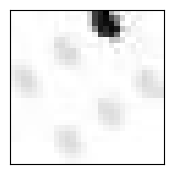

In [7]:
from core.brailleimages import seriestoimage
#from random import randint

# reconstruct random image
#img = seriestoimage(df.iloc[randint(0, df.shape[0]), :])
img = seriestoimage(df.iloc[1, :])

fig, ax = plt.subplots(figsize=(2, 2))
ax.imshow(img, cmap='gray')
ax.set_xticks([])
ax.set_yticks([]);

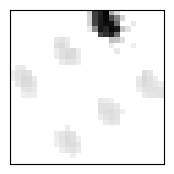

In [ ]:
# check if light values should be converted to white 
# and dark values to black
df_num = df.iloc[:, :-3]
mask_white = df_num.ge(240) & df_num.lt(255)
mask_white.sum(axis=1) # yes

# let's try it with index 1
img1 = seriestoimage(df.iloc[1, :].replace(range(240, 255), [255] * 15))

fig, ax = plt.subplots(figsize=(2, 2))
ax.imshow(img1, cmap='gray')
ax.set_xticks([])
ax.set_yticks([]);